In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool
from sk.features import extract_features
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
sample_rate = 22050
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
times = 4
audio_files_meta = "metadata.csv"

In [3]:
full_df = pd.read_csv("metadata_augmented.csv")
full_df['original_stem'] = full_df['file_name'].apply(lambda x: x.split('__')[0].replace('.wav', ''))

groups = full_df['original_stem'].values

In [4]:
if __name__ == '__main__':

    file_paths = []
    for _, row in full_df.iterrows():
        fname = row["file_name"]
        if not fname.endswith(".wav"):
            fname += ".wav"
            
        if row["augmentation"] == "original":
            path = os.path.join("audio_files", fname)
        else:
            path = os.path.join("audio_files_augmented", fname)
            
        file_paths.append(path)

    start = time.time()
    results = []
    completed = 0

    with Pool(processes=6) as pool:
        for features in pool.imap(extract_features, file_paths):
            results.append(features)
            completed += 1
            if completed % 60 == 0:
                elapsed = time.time() - start
                print(f"[{completed}/{len(file_paths)}] {elapsed:.1f}s — {elapsed/completed:.2f}s/file")

    X = np.array(results)
    print(f"Done — {time.time()-start:.1f}s total, shape: {X.shape}")


    y_emotion_raw = np.array(full_df["emotion"].tolist())    

    emotion_encoder = LabelEncoder()
    y_emotion = emotion_encoder.fit_transform(y_emotion_raw)

    os.makedirs("models", exist_ok=True)
    np.save("models/X_features_emotion_only.npy", X)
    np.save("models/y_emotion_only.npy", y_emotion)
    
    print("Features and emotion labels saved successfully.")
    print(f"Emotion classes: {emotion_encoder.classes_}")

[60/3360] 6.2s — 0.10s/file
[120/3360] 10.4s — 0.09s/file
[180/3360] 14.9s — 0.08s/file
[240/3360] 19.2s — 0.08s/file
[300/3360] 23.1s — 0.08s/file
[360/3360] 27.2s — 0.08s/file
[420/3360] 31.2s — 0.07s/file
[480/3360] 35.2s — 0.07s/file
[540/3360] 39.2s — 0.07s/file
[600/3360] 43.7s — 0.07s/file
[660/3360] 48.6s — 0.07s/file
[720/3360] 50.3s — 0.07s/file
[780/3360] 51.2s — 0.07s/file
[840/3360] 52.3s — 0.06s/file
[900/3360] 53.2s — 0.06s/file
[960/3360] 54.3s — 0.06s/file
[1020/3360] 55.4s — 0.05s/file
[1080/3360] 56.6s — 0.05s/file
[1140/3360] 57.8s — 0.05s/file
[1200/3360] 59.0s — 0.05s/file
[1260/3360] 60.0s — 0.05s/file
[1320/3360] 61.0s — 0.05s/file
[1380/3360] 62.2s — 0.05s/file
[1440/3360] 63.2s — 0.04s/file
[1500/3360] 64.4s — 0.04s/file
[1560/3360] 65.6s — 0.04s/file
[1620/3360] 66.5s — 0.04s/file
[1680/3360] 67.5s — 0.04s/file
[1740/3360] 68.5s — 0.04s/file
[1800/3360] 69.5s — 0.04s/file
[1860/3360] 70.4s — 0.04s/file
[1920/3360] 71.4s — 0.04s/file
[1980/3360] 72.6s — 0.04s/

In [5]:
joblib.dump(emotion_encoder, os.path.join("models", "svm_emotion_encoder_single.pkl"))

['models/svm_emotion_encoder_single.pkl']

Train size: 2685 | Test size: 675
Fitting 5 folds for each of 9 candidates, totalling 45 fits



Best params: {'estimator__C': 10, 'estimator__gamma': 0.01, 'estimator__kernel': 'rbf'}
Emotion on Test  Data
              precision    recall  f1-score   support

       angry       0.49      0.48      0.48       105
        calm       0.70      0.73      0.72       140
     disgust       0.28      0.42      0.33        65
     fearful       0.45      0.36      0.40        70
       happy       0.30      0.26      0.28        95
         sad       0.25      0.16      0.19        90
   surprised       0.38      0.47      0.42       110

    accuracy                           0.44       675
   macro avg       0.41      0.41      0.40       675
weighted avg       0.43      0.44      0.43       675



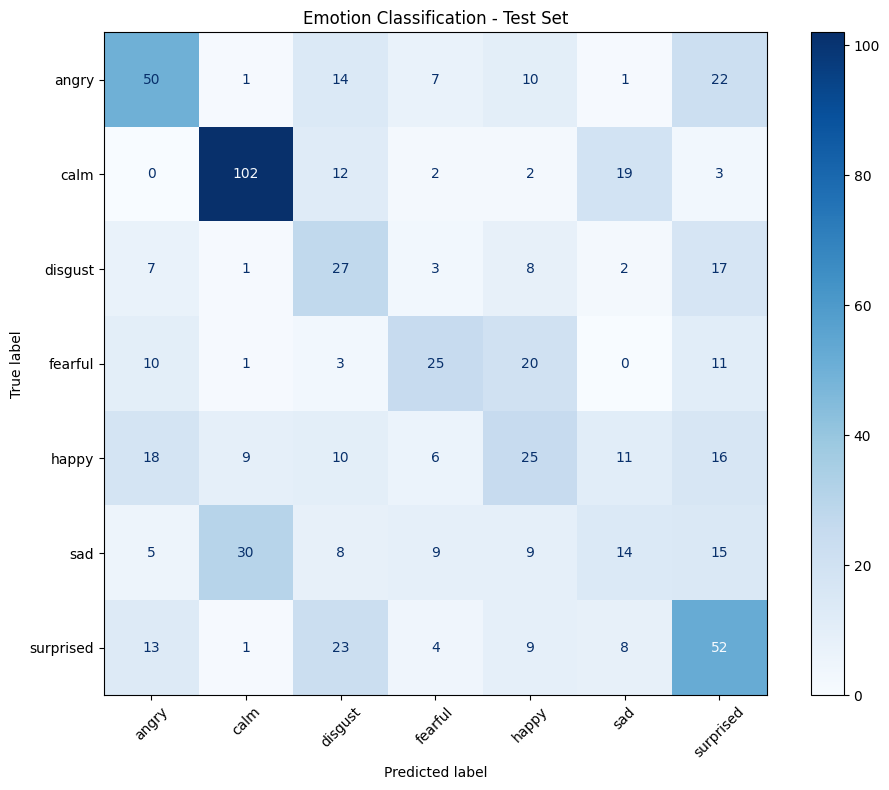

In [6]:
X = np.load("models/X_features_emotion_only.npy")
y_emotion = np.load("models/y_emotion_only.npy")

groups = np.asarray(groups)
if len(groups) != len(X):
    groups = groups[:len(X)]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_emotion, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_emotion[train_idx], y_emotion[test_idx]

groups_train = groups[train_idx]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

param_grid = {
    "estimator__C": [0.1, 1, 10],
    "estimator__gamma": ["scale", 0.001, 0.01],
    "estimator__kernel": ["rbf"],
}

svm_emotion = Pipeline([
    ("scaler", StandardScaler()),
    ("estimator", SVC(class_weight="balanced", probability=True)),
])

gkf = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    svm_emotion,
    param_grid,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train, groups=groups_train)

print(f"\nBest params: {grid_search.best_params_}")

joblib.dump(grid_search, os.path.join("models", "svm_emotion_single.pkl"))

y_pred = grid_search.predict(X_test)

print("Emotion on Test  Data")
print(classification_report(y_test, y_pred, target_names=emotion_encoder.classes_))

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=emotion_encoder.classes_).plot(
    ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45
)
ax.set_title("Emotion Classification - Test Set")
plt.tight_layout()
plt.show()

/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small

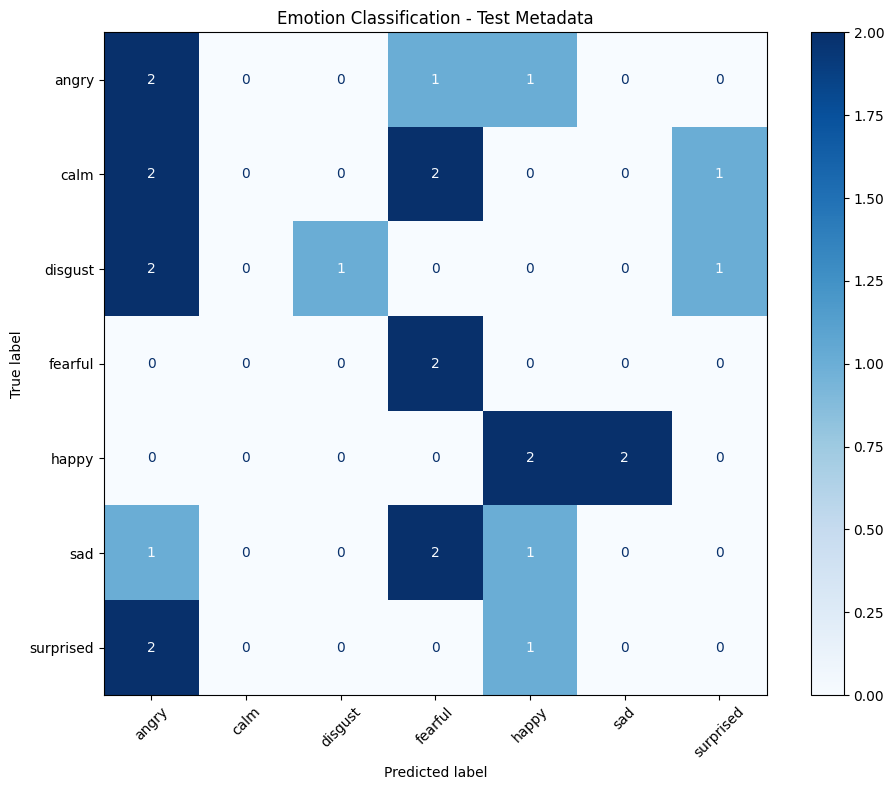

Emotion Classification

Accuracy: 26.92%
Mean Confidence: 53.36%
Metrics
              precision    recall  f1-score   support

       angry       0.22      0.50      0.31         4
        calm       0.00      0.00      0.00         5
     disgust       1.00      0.25      0.40         4
     fearful       0.29      1.00      0.44         2
       happy       0.40      0.50      0.44         4
         sad       0.00      0.00      0.00         4
   surprised       0.00      0.00      0.00         3

    accuracy                           0.27        26
   macro avg       0.27      0.32      0.23        26
weighted avg       0.27      0.27      0.21        26



In [7]:
emotion_encoder = joblib.load(os.path.join("models", "svm_emotion_encoder_single.pkl"))
svm_emotion_model = joblib.load(os.path.join("models", "svm_emotion_single.pkl"))


test_metadata = pd.read_csv('test_metadata_master.csv')

true_emotions = []
pred_emotions = []
pred_probs = []

for _, row in test_metadata.iterrows():
    file_path = row['file_path']
    try:
        feature = extract_features(file_path)
        feature_2d = feature.reshape(1, -1)
        prediction = svm_emotion_model.predict(feature_2d)[0]
        proba = svm_emotion_model.predict_proba(feature_2d)[0].max()
        
        predicted_emotion = emotion_encoder.inverse_transform([prediction])[0]
        
        true_emotions.append(str(row['Emotion']).lower())
        pred_emotions.append(predicted_emotion)
        pred_probs.append(proba)
    except Exception as e:
        print(f"Error processing {file_path}: {type(e).__name__}: {e}")

if len(true_emotions) > 0:
    from sklearn.metrics import accuracy_score
    
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
    ConfusionMatrixDisplay(cm, display_labels=emotion_encoder.classes_).plot(
        ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45
    )
    ax.set_title("Emotion Classification - Test Metadata")
    plt.tight_layout()
    plt.show()
    
    emotion_acc = accuracy_score(true_emotions, pred_emotions)
    print("Emotion Classification\n")
    print(f"Accuracy: {emotion_acc:.2%}")
    print(f"Mean Confidence: {np.mean(pred_probs):.2%}")
    
    print("Metrics")
    print(classification_report(
        true_emotions,
        pred_emotions,
        labels=emotion_encoder.classes_,
        target_names=emotion_encoder.classes_,
        zero_division=0
    ))
else:
    print("No predictions were collected.")